### 1. DEPENDENCIES

In [48]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### 2. DATASET

In [49]:
#load dataset
df = pd.read_csv('iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [50]:
#missing values
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

### 3. FEATURES AND TARGET

In [51]:
X = df.drop('species', axis=1)
y = df['species']

### 4. STANDARDIZE FEATURES

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 5. K-MEANS

In [53]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [54]:
#cluster prediction
clusters = kmeans.labels_
clusters

array([1, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 2, 2, 1, 1, 2, 2, 1,
       1, 2, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [55]:
# add cluster labels to original dataframe
df['cluster'] = clusters


### 5. PCA

In [56]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### 6. CREATE A PCA DATAFRAME

In [57]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

pca_df['cluster'] = clusters
pca_df['species'] = y

In [58]:
pca.explained_variance_ratio_

array([0.72770452, 0.23030523])

#### Interpretation:

PC1 explains ~73% variance
PC2 explains ~23% variance

Total retained information ≈ 96%

### 7. VISUALIZATION

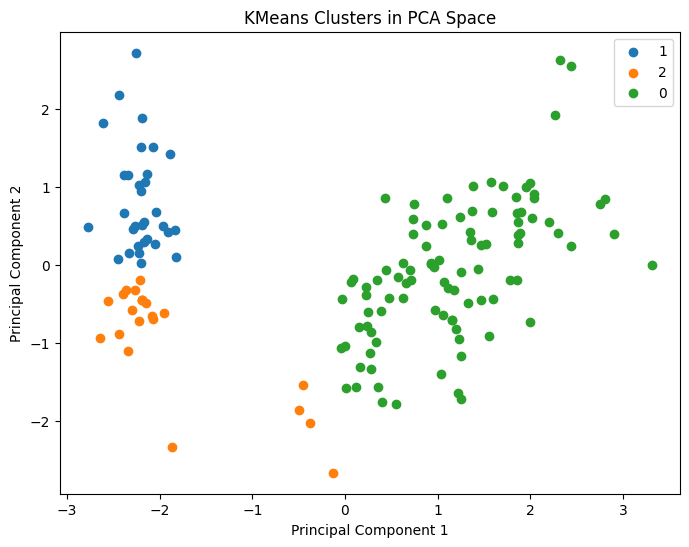

In [59]:
#visualize kmeans clusters
fg, ax = plt.subplots(figsize=(8, 6))

for cluster in pca_df['cluster'].unique():
    subset = pca_df[pca_df['cluster'] == cluster]
    ax.scatter(subset['PC1'], subset['PC2'], label=cluster)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('KMeans Clusters in PCA Space')
ax.legend()
plt.show()

#### The PCA scatter plot shows:

Clear separation of setosa
Partial overlap between versicolor and virginica

This demonstrates how PCA helps visualize high-dimensional data.

In [60]:
#compare with actual species
print(pd.crosstab(df['cluster'], df['species']))

species  setosa  versicolor  virginica
cluster                               
0             0          46         50
1            32           0          0
2            18           4          0


#### Interpretation
 - Setosa

Perfectly clustered.

 - Versicolor & Virginica

Some overlap exists because their measurements are similar.

In [61]:
#cluster centers
print('kmeans.cluster_centers_')

kmeans.cluster_centers_


### ELBOW METHOD

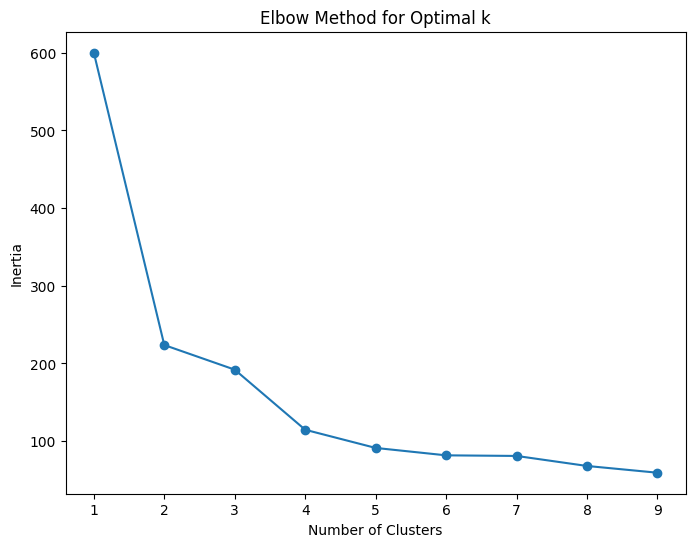

In [62]:
inertia = []
k = range(1, 10)
for i in k:
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)
plt.figure(figsize=(8, 6))
plt.plot(k, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

#### - Inertia measures how close data points are to the cluster centre

    -  The optimal K is 3